# Normal Distribution in E-commerce Analytics

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 

In [9]:
data = pd.read_csv('cleaned_retail_data.csv',parse_dates=['OrderDate'])

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6610 entries, 0 to 6609
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   OrderID               6610 non-null   object        
 1   OrderDate             6610 non-null   datetime64[ns]
 2   CustomerID            6610 non-null   object        
 3   CustomerAge           6610 non-null   int64         
 4   Region                6610 non-null   object        
 5   State                 6610 non-null   object        
 6   Category              6610 non-null   object        
 7   SubCategory           6610 non-null   object        
 8   Quantity              6610 non-null   float64       
 9   UnitPrice             6610 non-null   float64       
 10  Discount              6610 non-null   float64       
 11  Sales                 6610 non-null   float64       
 12  Profit                6610 non-null   float64       
 13  DeliveryDays      

In [11]:
data.isnull().sum()

OrderID                 0
OrderDate               0
CustomerID              0
CustomerAge             0
Region                  0
State                   0
Category                0
SubCategory             0
Quantity                0
UnitPrice               0
Discount                0
Sales                   0
Profit                  0
DeliveryDays            0
CustomerMonthlySpend    0
CustomerRating          0
PaymentMode             0
ShippingCost            0
dtype: int64

# 

## 1. Delivery & Logistics Analysis (DeliveryDays)

#### Objective : 
Analyze delivery performance to identify delays, measure consistency, and improve customer satisfact

#### 1. What is the average delivery time, and how consistent are deliveries across all orders?

In [12]:
avg_delivery = data['DeliveryDays'].mean()

In [13]:
avg_delivery

np.float64(4.207881996974281)

In [14]:
std_delivery = data['DeliveryDays'].std()

In [16]:
print('Average Delivery Time:', round(avg_delivery, 2))
print('Standard Deviation: ', round(std_delivery, 2))

Average Delivery Time: 4.21
Standard Deviation:  1.32


- The standard deviation indicates how much delivery times vary around the average.
- A lower standard deviation means deliveries are more consistent.

# 

#### 2. What percentage of orders are delivered within the normal delivery time (μ ± 1σ)?

In [18]:
avg_delivery = data["DeliveryDays"].mean()
std_delivery = data["DeliveryDays"].std()

In [19]:
lower_DDyas = avg_delivery - std_delivery
upper_DDyas = avg_delivery + std_delivery

In [21]:
lower_DDyas

np.float64(2.8853409788067483)

In [22]:
upper_DDyas

np.float64(5.530423015141814)

##### delivered within the normal delivery  window (μ ± 1σ)

In [25]:
within_1std = data[(data["DeliveryDays"] >= lower_DDyas) &(data["DeliveryDays"] <= upper_DDyas)]

In [27]:
within_1std.head()

,OrderID,OrderDate,CustomerID,CustomerAge,Region,State,Category,SubCategory,Quantity,UnitPrice,Discount,Sales,Profit,DeliveryDays,CustomerMonthlySpend,CustomerRating,PaymentMode,ShippingCost
0,ORD100958,2024-08-28,CUST2386,39,West,Gujarat,Grocery,Beverages,4.0,290.93,0.15,989.16,124.16,5.3,14491.61,4.0,Net Banking,132.23
1,ORD104369,2024-10-18,CUST2188,38,Central,Madhya Pradesh,Clothing,Footwear,2.0,1136.09,0.17,1885.91,707.72,3.9,15646.89,5.0,Credit Card,122.23
3,ORD102892,2023-12-10,CUST3108,30,North,Uttar Pradesh,Electronics,Laptops,5.0,10591.15,0.17,43953.27,10569.14,4.5,13701.05,4.0,Upi,178.72
4,ORD101606,2024-11-11,CUST4137,26,Central,Chhattisgarh,Furniture,Tables,4.0,4739.55,0.06,17820.71,3072.61,3.8,8269.97,5.0,Debit Card,143.90
5,ORD104936,2023-06-30,CUST3601,18,Central,Chhattisgarh,Sports,Outdoor Gear,2.0,2454.28,0.14,4221.36,1378.03,4.1,15954.28,5.0,Debit Card,59.21


In [30]:
# Percentage
within_percentage = (len(within_1std) /len(data)) * 100

In [37]:
print(f'Orders Within Normal Window: {len(within_1std)}')
print(f'Percentage : {within_percentage:.2f}%')

Orders Within Normal Window: 4580
Percentage : 69.29%


# 

#### 3. How many orders were delivered much faster or much slower than normal?

In [39]:
unusual_orders = data[(data["DeliveryDays"] < lower_DDyas) |(data["DeliveryDays"] > upper_DDyas)]

In [40]:
unusual_orders.head()

,OrderID,OrderDate,CustomerID,CustomerAge,Region,State,Category,SubCategory,Quantity,UnitPrice,Discount,Sales,Profit,DeliveryDays,CustomerMonthlySpend,CustomerRating,PaymentMode,ShippingCost
2,ORD102315,2023-06-29,CUST2315,22,West,Gujarat,Furniture,Sofas,2.0,5060.29,0.04,9715.76,2944.27,2.5,6427.58,4.0,Upi,164.33
9,ORD107047,2023-03-28,CUST3996,29,West,Gujarat,Electronics,Accessories,2.0,5768.61,0.10,10383.50,3142.73,6.3,11233.40,4.0,Credit Card,164.19
14,ORD104315,2023-01-20,CUST1281,24,West,Rajasthan,Sports,Sportswear,5.0,3148.76,0.04,15114.05,3369.47,2.0,10069.22,2.0,Net Banking,88.57
21,ORD106294,2023-03-26,CUST2028,46,North,Uttar Pradesh,Sports,Sportswear,4.0,2779.10,0.10,10004.76,1033.82,2.2,10323.33,4.0,Upi,155.54
24,ORD106290,2024-07-11,CUST1819,18,East,West Bengal,Electronics,Cameras,9.0,8273.66,0.02,72973.68,9742.43,7.4,9558.17,3.0,Debit Card,37.35


In [41]:
unusual_count = len(unusual_orders)
total_orders = len(df)

In [44]:
unusual_percentage = (unusual_count / total_orders) * 100

In [46]:
print(f'Orders Outside No : {unusual_count}')
print(f'Percentage            : {unusual_percentage:.2f}%')

Orders Outside No : 2030
Percentage            : 30.71%


In [49]:
unusual_orders[['OrderID', 'DeliveryDays']].sample(10)

,OrderID,DeliveryDays
1557,ORD107225,1.2
5696,ORD104967,2.8
1625,ORD101487,6.3
6012,ORD107688,1.3
599,ORD101766,7.6
4066,ORD106807,2.0
4651,ORD107968,2.3
510,ORD104539,2.7
4264,ORD100416,5.8
6475,ORD106794,5.7


# 

#### 4 . Are there any orders with extremely unusual delivery times?

In [53]:
extremely_unusual_delivery = data[
    (data['DeliveryDays'] < avg_delivery - (3 * std_delivery) ) |
    (data['DeliveryDays'] > avg_delivery + (3 * std_delivery) ) ]

In [59]:
extremely_unusual_delivery[['OrderID', 'DeliveryDays']]

,OrderID,DeliveryDays
311,ORD107719,8.2
784,ORD107395,9.9
1219,ORD103440,9.1
1399,ORD102535,9.2
1813,ORD103538,8.5
2010,ORD101061,8.2
3806,ORD105807,9.3
5728,ORD103472,8.6
6357,ORD100395,8.9


In [55]:
extremely_unusual_counts =  len(extremely_unusual_delivery)

In [56]:
extremely_unusual_counts

9

In [57]:
ext_delay_percentage = (extremely_unusual_counts / total_orders) * 100

In [58]:
print(' Extremely unusual delivery Summary' )
print('-' * 40)
print(f'Total Orders              : {total_orders}')
print(f'Extremely Delay Orders       : {extremely_unusual_counts}')
print(f'Percentage                : {ext_delay_percentage:.2f}%')

 Extremely unusual delivery Summary
----------------------------------------
Total Orders              : 6610
Extremely Delay Orders       : 9
Percentage                : 0.14%


# 

#### 5.  Are severe delivery delays concentrated in specific Regions?

In [61]:
extremely_unusual_delivery

,OrderID,OrderDate,CustomerID,CustomerAge,Region,State,Category,SubCategory,Quantity,UnitPrice,Discount,Sales,Profit,DeliveryDays,CustomerMonthlySpend,CustomerRating,PaymentMode,ShippingCost
311,ORD107719,2024-08-01,CUST3342,30,West,Maharashtra,Electronics,Mobile Phones,3.0,6537.27,0.26,14512.74,3738.40,8.2,7952.28,4.0,Net Banking,87.38
784,ORD107395,2024-01-03,CUST3970,27,South,Andhra Pradesh,Sports,Fitness Equipment,1.0,2310.27,0.06,2171.65,521.66,9.9,9664.36,3.0,Cash On Delivery,181.39
1219,ORD103440,2024-01-20,CUST2914,42,East,Odisha,Electronics,Cameras,3.0,8852.69,0.14,22839.94,2850.72,9.1,13488.26,3.0,Upi,95.39
1399,ORD102535,2024-07-16,CUST2835,35,South,Andhra Pradesh,Furniture,Bookcases,2.0,7393.36,0.03,14343.12,3557.51,9.2,17070.70,1.0,Net Banking,106.34
1813,ORD103538,2023-01-19,CUST2050,28,Central,Madhya Pradesh,Furniture,Bookcases,5.0,5864.91,0.15,24925.87,1125.82,8.5,16588.98,4.0,Credit Card,76.65
2010,ORD101061,2024-10-30,CUST2741,40,East,Bihar,Home Decor,Wall Art,3.0,1258.91,0.16,3172.45,954.71,8.2,12370.97,4.0,Credit Card,154.89
3806,ORD105807,2024-04-24,CUST2759,34,Central,Chhattisgarh,Electronics,Laptops,3.0,8098.75,0.04,23324.40,6102.30,9.3,4320.22,5.0,Cash On Delivery,130.99
5728,ORD103472,2024-05-01,CUST2284,30,South,Karnataka,Clothing,Men Wear,3.0,1412.80,0.28,3051.65,564.04,8.6,12477.96,5.0,Net Banking,82.29
6357,ORD100395,2024-04-15,CUST1366,36,Central,Madhya Pradesh,Electronics,Cameras,3.0,5508.16,0.11,14706.79,1382.82,8.9,8054.83,5.0,Credit Card,130.73


In [68]:
region_delay = (extremely_unusual_delivery.groupby('Region').size().reset_index(name='extremely_unusual_counts')
    .sort_values(by='extremely_unusual_counts', ascending=False))

In [69]:
region_delay

,Region,extremely_unusual_counts
0,Central,3
2,South,3
1,East,2
3,West,1


#### 6. Which States have the highest number of severe delivery delays?

In [70]:
state_delay = (extremely_unusual_delivery.groupby('State').size().reset_index(name='extremely_unusual_counts')
    .sort_values(by='extremely_unusual_counts', ascending=False))

In [71]:
state_delay

,State,extremely_unusual_counts
0,Andhra Pradesh,2
4,Madhya Pradesh,2
1,Bihar,1
2,Chhattisgarh,1
3,Karnataka,1
5,Maharashtra,1
6,Odisha,1


#### 7. Does PaymentMode influence delivery delays?

In [73]:
payment_delay  = (extremely_unusual_delivery.groupby('PaymentMode').size().reset_index(name='extremely_unusual_counts')
    .sort_values(by='extremely_unusual_counts', ascending=False))

In [74]:
payment_delay

,PaymentMode,extremely_unusual_counts
1,Credit Card,3
2,Net Banking,3
0,Cash On Delivery,2
3,Upi,1


# 

## 2. Fraud, Errors & Revenue Integrity Analysis (Sales & CustomerMonthlySpend)

#### Objective:
Identify unusual sales and customer spending patterns to detect fraud, pricing errors, and revenue risks.

#### 1. Are there any orders with unusually high or unusually low Sales values?

In [75]:
sales_mean = data['Sales'].mean()
sales_std =data['Sales'].std()

In [76]:
sales_mean

np.float64(10501.38512405446)

In [77]:
sales_std

12037.015082369515

In [78]:
sales_lower3 = sales_mean -(3* sales_std)
sales_upper3 = sales_mean +(3* sales_std)

In [79]:
unusuall_sales = data[(data["Sales"] > sales_upper3 )|(data['Sales']<sales_lower3)]

In [80]:
unusuall_sales.head()

,OrderID,OrderDate,CustomerID,CustomerAge,Region,State,Category,SubCategory,Quantity,UnitPrice,Discount,Sales,Profit,DeliveryDays,CustomerMonthlySpend,CustomerRating,PaymentMode,ShippingCost
7,ORD103423,2024-11-04,CUST3305,21,West,Gujarat,Electronics,Accessories,8.0,7539.39,0.07,56093.06,14616.88,5.0,15405.53,4.0,Upi,148.59
24,ORD106290,2024-07-11,CUST1819,18,East,West Bengal,Electronics,Cameras,9.0,8273.66,0.02,72973.68,9742.43,7.4,9558.17,3.0,Debit Card,37.35
35,ORD107129,2024-02-01,CUST4212,30,South,Kerala,Electronics,Laptops,5.0,11963.74,0.06,56229.58,-2182.43,4.2,16295.17,3.0,Cash On Delivery,129.05
54,ORD105816,2024-12-10,CUST2049,18,East,Odisha,Electronics,Mobile Phones,9.0,9650.91,0.03,84252.44,9417.31,3.3,11811.45,5.0,Credit Card,45.18
70,ORD104623,2023-03-14,CUST3962,60,North,Delhi,Electronics,Headphones,7.0,8693.40,0.14,52334.27,9486.86,3.9,11136.78,4.0,Net Banking,70.92


In [88]:
print("Total Sales Outliers:", len(unusuall_sales))

Total Sales Outliers: 129


In [89]:
unusuall_sales[["OrderID", "Category", "SubCategory", "Sales"]].sort_values(by="Sales", ascending=False)

,OrderID,Category,SubCategory,Sales
4603,ORD102196,Electronics,Mobile Phones,96890.28
4749,ORD107463,Electronics,Cameras,91756.00
4474,ORD106944,Electronics,Cameras,89912.02
5387,ORD103421,Electronics,Cameras,89553.35
54,ORD105816,Electronics,Mobile Phones,84252.44
...,...,...,...,...
3126,ORD105449,Electronics,Accessories,46930.85
5268,ORD101715,Electronics,Accessories,46930.59
3373,ORD100641,Furniture,Bookcases,46830.75
6269,ORD105431,Electronics,Accessories,46817.00


#### 2. What is the total Sales value associated with Sales outliers?

In [102]:
total_sales = data["Sales"].sum()
total_outlier_sales = unusuall_sales["Sales"].sum()
sales_percentage = (total_outlier_sales / total_sales) * 100

print(f'Total Sales Value           : {total_sales:,.2f}')
print(f'Outlier Sales Value         : {total_outlier_sales:.2f}')
print(f'Percentage of Total Sales   : {sales_percentage:.2f}%')

Total Sales Value           : 69,414,155.67
Outlier Sales Value         : 7441769.75
Percentage of Total Sales   : 10.72%


# 

#### 3. Are any customers spending significantly more or less than the average monthly customer?

In [103]:
data.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerAge', 'Region', 'State',
       'Category', 'SubCategory', 'Quantity', 'UnitPrice', 'Discount', 'Sales',
       'Profit', 'DeliveryDays', 'CustomerMonthlySpend', 'CustomerRating',
       'PaymentMode', 'ShippingCost'],
      dtype='object')

In [104]:
M_spend_mean = data['CustomerMonthlySpend'].mean()
M_spend_std = data['CustomerMonthlySpend'].std()

In [105]:
lower_spend = M_spend_mean - (3* M_spend_std)
upper_spend = M_spend_mean + (3* M_spend_std)

In [111]:
print("Mean Spend : " ,round(M_spend_mean,2))
print('Standard Devition : ', round(M_spend_std,2))

Mean Spend :  12506.66
Standard Devition :  3731.34


In [110]:
print(" Lower Spend : ",round(lower_spend,2))
print(" Upper Spend : ",round(upper_spend,2))

 Lower Spend :  1312.65
 Upper Spend :  23700.67


In [112]:
# Customers with Unusual Monthly Spend
abnormal_cust = data[(data['CustomerMonthlySpend']< lower_spend)|(data['CustomerMonthlySpend']> upper_spend)]

In [114]:
print(f"\nTotal Abnormal Customers: {len(abnormal_cust)}")


Total Abnormal Customers: 16


# 

#### 4. Which customers have abnormal CustomerMonthlySpend values based on Three-Sigma analysis?

In [115]:
abnormal_cust

,OrderID,OrderDate,CustomerID,CustomerAge,Region,State,Category,SubCategory,Quantity,UnitPrice,Discount,Sales,Profit,DeliveryDays,CustomerMonthlySpend,CustomerRating,PaymentMode,ShippingCost
435,ORD107654,2024-01-24,CUST2345,23,West,Maharashtra,Sports,Fitness Equipment,3.0,1111.41,0.26,2467.33,326.83,2.2,24336.69,4.0,Credit Card,82.33
555,ORD103387,2024-07-10,CUST3440,24,East,Bihar,Grocery,Beverages,7.0,462.19,0.22,2523.56,314.49,3.3,23942.16,4.0,Credit Card,131.15
638,ORD100888,2024-05-20,CUST1371,38,South,Tamil Nadu,Sports,Sportswear,1.0,692.42,0.24,526.24,64.12,3.4,1054.41,4.0,Cash On Delivery,146.91
2441,ORD101796,2024-11-03,CUST1715,36,North,Uttar Pradesh,Electronics,Mobile Phones,2.0,10837.99,0.09,19725.14,1950.35,7.0,24012.80,4.0,Cash On Delivery,161.23
2831,ORD104343,2023-09-23,CUST3169,23,South,Tamil Nadu,Grocery,Dairy,5.0,282.39,0.12,1242.52,106.15,5.1,24726.80,5.0,Credit Card,159.50
3313,ORD103747,2023-08-23,CUST1381,45,Central,Madhya Pradesh,Sports,Fitness Equipment,2.0,2731.50,0.05,5189.85,1260.57,3.7,500.00,4.0,Net Banking,105.36
3394,ORD103133,2024-11-25,CUST1079,44,Central,Chhattisgarh,Clothing,Footwear,3.0,1238.99,0.09,3382.44,359.71,3.9,24195.75,5.0,Debit Card,42.41
3652,ORD107187,2023-10-21,CUST3363,44,East,Bihar,Clothing,Men Wear,2.0,1847.31,0.36,2364.56,546.19,4.1,24125.85,3.0,Net Banking,56.12
3862,ORD105302,2023-05-29,CUST2138,28,Central,Chhattisgarh,Grocery,Beverages,3.0,254.09,0.09,693.67,107.40,5.4,500.00,4.0,Upi,115.70
4870,ORD102491,2024-07-25,CUST4036,40,South,Kerala,Electronics,Headphones,4.0,14441.02,0.02,56608.80,14601.38,5.9,500.00,5.0,Debit Card,83.65


In [117]:
 abnormal_cust[["CustomerID","OrderID","CustomerMonthlySpend","Sales","Profit","Category","SubCategory","Region","State","PaymentMode"]].sort_values(by="CustomerMonthlySpend", ascending=False)

,CustomerID,OrderID,CustomerMonthlySpend,Sales,Profit,Category,SubCategory,Region,State,PaymentMode
5104,CUST2357,ORD102682,27113.79,19674.09,3655.78,Electronics,Laptops,North,Uttar Pradesh,Net Banking
5416,CUST4039,ORD100679,25919.02,1703.27,-1.53,Home Decor,Lighting,South,Kerala,Cash On Delivery
2831,CUST3169,ORD104343,24726.80,1242.52,106.15,Grocery,Dairy,South,Tamil Nadu,Credit Card
435,CUST2345,ORD107654,24336.69,2467.33,326.83,Sports,Fitness Equipment,West,Maharashtra,Credit Card
5847,CUST3103,ORD100135,24280.71,2856.62,816.48,Home Decor,Curtains,West,Goa,Debit Card
3394,CUST1079,ORD103133,24195.75,3382.44,359.71,Clothing,Footwear,Central,Chhattisgarh,Debit Card
3652,CUST3363,ORD107187,24125.85,2364.56,546.19,Clothing,Men Wear,East,Bihar,Net Banking
2441,CUST1715,ORD101796,24012.80,19725.14,1950.35,Electronics,Mobile Phones,North,Uttar Pradesh,Cash On Delivery
555,CUST3440,ORD103387,23942.16,2523.56,314.49,Grocery,Beverages,East,Bihar,Credit Card
6143,CUST1652,ORD102366,1286.29,18688.08,1244.47,Furniture,Chairs,Central,Chhattisgarh,Credit Card


# 

#### 5. Which Regions generate the highest concentration of revenue outliers?

In [125]:
# Region-wise Count
region_outliers = (abnormal_cust.groupby("Region").size().reset_index(name="Outlier_Count").sort_values(by="Outlier_Count", ascending=False))
print("Region-wise Sales Outliers")
print(region_outliers)

Region-wise Sales Outliers
    Region  Outlier_Count
0  Central              5
3    South              5
1     East              2
2    North              2
4     West              2


In [126]:
abnormal_cust.groupby("Region")['Sales'].sum()

Region
Central    69734.31
East        4888.12
North      39399.23
South      90552.23
West        5323.95
Name: Sales, dtype: float64

# 

#### 6. Which Categories contribute the most to abnormal Sales values?

In [127]:
abnormal_cust.groupby(['Category'])['Sales'].sum()

Category
Clothing         5747.00
Electronics    137788.30
Furniture       49159.48
Grocery          4459.75
Home Decor       4559.89
Sports           8183.42
Name: Sales, dtype: float64

In [138]:
category_outliers = (abnormal_cust.groupby("Category").agg(Outlier_Count=("OrderID", "count"),Total_Outlier_Sales=("Sales", "sum"),
    Average_Outlier_Sales=("Sales", "mean"))
    .reset_index()
    .sort_values(by="Total_Outlier_Sales", ascending=False)
)

In [139]:
category_outliers

,Category,Outlier_Count,Total_Outlier_Sales,Average_Outlier_Sales
1,Electronics,4,137788.30,34447.075000
2,Furniture,2,49159.48,24579.740000
5,Sports,3,8183.42,2727.806667
0,Clothing,2,5747.00,2873.500000
4,Home Decor,2,4559.89,2279.945000
3,Grocery,3,4459.75,1486.583333


# 

# 

## 3. Customer Segmentation Analysis (CustomerAge & CustomerRating)

#### Objective : 
Understand customer behavior by analyzing age and ratings to identify unique customer segments and improve marketing strategies.

#### 1. What is the average customer age?

In [151]:
# Calculate Mean Age
age_mean = data["CustomerAge"].mean()

# Calculate Standard Deviation
age_std = data["CustomerAge"].std()

print(f'Average Customer Age : {age_mean:.2f} Years')
print(f'Standard Deviation   : {age_std:.2f} Years')

Average Customer Age : 35.21 Years
Standard Deviation   : 10.29 Years


# 

#### 2. Are customers concentrated within a narrow age range or spread across multiple age groups?

In [158]:
# Create Age Groups
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ["Below 18","18-25","26-35","36-45","46-55","56-65","65+"]

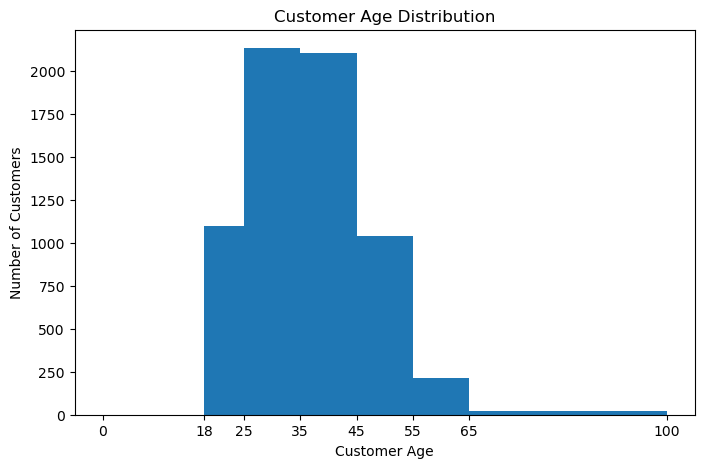

In [159]:
plt.figure(figsize=(8,5))
plt.hist(data["CustomerAge"], bins=age_bins)
plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.xticks(age_bins)
plt.ylabel("Number of Customers")
plt.show()

In [160]:
data["AgeGroup"] = pd.cut(data["CustomerAge"],bins=age_bins,labels=age_labels,include_lowest=True)

In [161]:
data

,OrderID,OrderDate,CustomerID,CustomerAge,Region,State,Category,SubCategory,Quantity,UnitPrice,Discount,Sales,Profit,DeliveryDays,CustomerMonthlySpend,CustomerRating,PaymentMode,ShippingCost,AgeGroup
0,ORD100958,2024-08-28,CUST2386,39,West,Gujarat,Grocery,Beverages,4.0,290.93,0.15,989.16,124.16,5.3,14491.61,4.0,Net Banking,132.23,36-45
1,ORD104369,2024-10-18,CUST2188,38,Central,Madhya Pradesh,Clothing,Footwear,2.0,1136.09,0.17,1885.91,707.72,3.9,15646.89,5.0,Credit Card,122.23,36-45
2,ORD102315,2023-06-29,CUST2315,22,West,Gujarat,Furniture,Sofas,2.0,5060.29,0.04,9715.76,2944.27,2.5,6427.58,4.0,Upi,164.33,18-25
3,ORD102892,2023-12-10,CUST3108,30,North,Uttar Pradesh,Electronics,Laptops,5.0,10591.15,0.17,43953.27,10569.14,4.5,13701.05,4.0,Upi,178.72,26-35
4,ORD101606,2024-11-11,CUST4137,26,Central,Chhattisgarh,Furniture,Tables,4.0,4739.55,0.06,17820.71,3072.61,3.8,8269.97,5.0,Debit Card,143.90,26-35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6605,ORD101737,2024-06-03,CUST3886,35,West,Maharashtra,Clothing,Men Wear,3.0,725.76,0.28,1567.64,460.97,4.9,4902.39,5.0,Credit Card,109.50,26-35
6606,ORD103240,2024-05-08,CUST1166,32,East,Odisha,Grocery,Staples,5.0,410.96,0.14,1767.13,505.94,5.3,13681.25,4.0,Net Banking,137.06,26-35
6607,ORD105305,2024-12-26,CUST3552,23,East,Bihar,Clothing,Footwear,2.0,1678.22,0.22,2618.02,416.13,4.3,14289.81,4.0,Upi,126.94,18-25
6608,ORD107203,2023-04-20,CUST2094,18,South,Kerala,Home Decor,Curtains,3.0,1678.26,0.12,4430.61,229.35,2.7,13512.08,5.0,Net Banking,162.83,Below 18


In [165]:
age_distribution = (data["AgeGroup"].value_counts().sort_index().reset_index())

In [166]:
age_distribution

,AgeGroup,count
0,Below 18,434
1,18-25,834
2,26-35,2215
3,36-45,2014
4,46-55,914
5,56-65,183
6,65+,16


In [167]:
age_distribution.columns = ["Age Group", "Number of Customers"]

In [168]:
age_distribution

,Age Group,Number of Customers
0,Below 18,434
1,18-25,834
2,26-35,2215
3,36-45,2014
4,46-55,914
5,56-65,183
6,65+,16


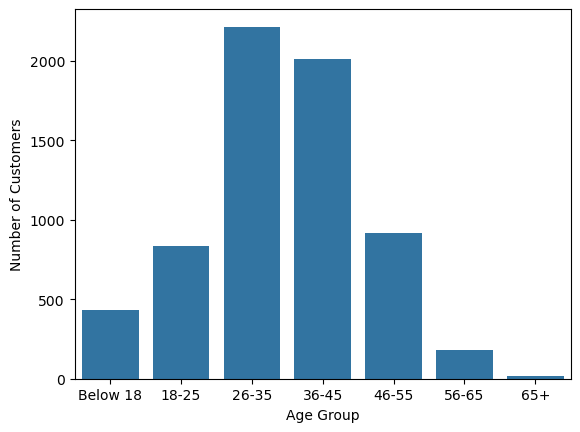

In [171]:
sns.barplot(data= age_distribution, x='Age Group', y = 'Number of Customers')
plt.show()

#### 3. Which customers have Age Z-Scores greater than ±2.5?

In [172]:
data['Age_Z_Score'] = (data['CustomerAge']- age_mean )/age_std

In [174]:
data[['CustomerID','CustomerAge','Age_Z_Score']].head()

,CustomerID,CustomerAge,Age_Z_Score
0,CUST2386,39,0.368778
1,CUST2188,38,0.271569
2,CUST2315,22,-1.283783
3,CUST3108,30,-0.506107
4,CUST4137,26,-0.894945


In [177]:
extreme_age_customers = data[data['Age_Z_Score'].abs()>2.5]

In [182]:
extreme_age_customers[['CustomerID','Region','State','CustomerAge','Age_Z_Score','Category','CustomerMonthlySpend']].head()

,CustomerID,Region,State,CustomerAge,Age_Z_Score,Category,CustomerMonthlySpend
266,CUST3293,South,Kerala,70,3.382272,Grocery,11079.64
315,CUST3608,South,Kerala,70,3.382272,Furniture,10614.41
330,CUST3012,East,Jharkhand,62,2.604596,Grocery,6285.88
603,CUST1106,South,Andhra Pradesh,61,2.507387,Sports,11941.35
617,CUST1368,East,Jharkhand,61,2.507387,Electronics,8834.52


In [184]:
print('Total Extreme Customers:',len(extreme_age_customers))


Total Extreme Customers: 59


# 

#### 4. What is the average customer rating?

In [186]:
Cust_Avg_rating = data['CustomerRating'].mean()

In [189]:
print('Average Customer Rating : ',round(Cust_Avg_rating,2))

Average Customer Rating :  3.87


# 

#### 5. Which customers provide ratings significantly above or below the average? /  Which ratings have absolute Z-Scores greater than 2.5?


In [190]:
Cust_Std_rating = data['CustomerRating'].std()

In [209]:
data["Rating_Z_Score"] = (data["CustomerRating"] - Cust_Avg_rating) / Cust_Std_rating

In [210]:
data[["CustomerID","OrderID","CustomerRating","Rating_Z_Score"]].head()

,CustomerID,OrderID,CustomerRating,Rating_Z_Score
0,CUST2386,ORD100958,4.0,0.120963
1,CUST2188,ORD104369,5.0,1.046390
2,CUST2315,ORD102315,4.0,0.120963
3,CUST3108,ORD102892,4.0,0.120963
4,CUST4137,ORD101606,5.0,1.046390


In [213]:
extreme_rating = data[data["Rating_Z_Score"].abs() > 2.5]

In [214]:
extreme_rating[["CustomerID","OrderID","CustomerRating","Rating_Z_Score"]].head()

,CustomerID,OrderID,CustomerRating,Rating_Z_Score
34,CUST4306,ORD101207,1.0,-2.655315
38,CUST2656,ORD101646,1.0,-2.655315
64,CUST1245,ORD106340,1.0,-2.655315
85,CUST3849,ORD105025,1.0,-2.655315
88,CUST4002,ORD107479,1.0,-2.655315


In [215]:
print('Total Customers : ', len(extreme_rating))

Total Customers :  273


# 

#### 6 . Which product categories receive the lowest customer ratings?

In [222]:
category_rating = (data.groupby("Category")["CustomerRating"].mean()
      .reset_index()
      .sort_values(by='CustomerRating', ascending=True)
)

In [223]:
print(category_rating)

      Category  CustomerRating
5       Sports        3.812048
4   Home Decor        3.835705
2    Furniture        3.855566
3      Grocery        3.864786
1  Electronics        3.895437
0     Clothing        3.908676


#### 7. Which product subcategories receive the lowest customer ratings?

In [225]:
subcategory_rating = (
    df.groupby("SubCategory")["CustomerRating"].mean()
      .reset_index()
      .sort_values(by='CustomerRating', ascending=True)
)

In [227]:
print(subcategory_rating)

          SubCategory  CustomerRating
20            Staples        3.727969
7   Fitness Equipment        3.772727
4              Chairs        3.782609
12           Lighting        3.788571
19         Sportswear        3.791667
23           Wall Art        3.812834
18              Sofas        3.820628
5            Curtains        3.834951
11            Laptops        3.841642
22             Tables        3.841860
24         Women Wear        3.842424
1           Beverages        3.854839
15       Outdoor Gear        3.864238
2           Bookcases        3.867470
17             Snacks        3.875472
3             Cameras        3.894737
16               Rugs        3.897561
10          Kids Wear        3.902280
9          Headphones        3.906897
14      Mobile Phones        3.911032
0         Accessories        3.931148
8            Footwear        3.938596
13           Men Wear        3.949254
21            Storage        3.974093
6               Dairy        4.003937


# 

#### 8. Does longer DeliveryDays result in lower CustomerRatings?

In [229]:
correlation = data['DeliveryDays'].corr(data["CustomerRating"])

In [230]:
correlation

np.float64(0.002097405229585039)

In [232]:
print('Correlation between Delivery Days and Customer Rating:',round(correlation,4))

Correlation between Delivery Days and Customer Rating: 0.0021


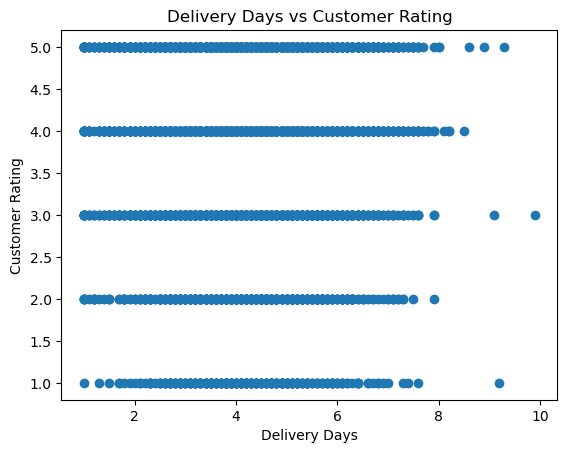

In [238]:
plt.scatter( data['DeliveryDays'], data["CustomerRating"])
plt.title("Delivery Days vs Customer Rating")
plt.xlabel("Delivery Days")
plt.ylabel("Customer Rating")
plt.show()

##### No Relationship between Delivery Days and Customer Rating

# 

#### 9. Is there a relationship between Age_Z_Score and Rating_Z_Score?

In [239]:
data.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerAge', 'Region', 'State',
       'Category', 'SubCategory', 'Quantity', 'UnitPrice', 'Discount', 'Sales',
       'Profit', 'DeliveryDays', 'CustomerMonthlySpend', 'CustomerRating',
       'PaymentMode', 'ShippingCost', 'AgeGroup', 'Age_Z_Score',
       'Rating_Z_Score'],
      dtype='object')

In [240]:
correlation = data["Age_Z_Score"].corr(data["Rating_Z_Score"])
print('Correlation :', round(correlation,2))

Correlation : -0.01


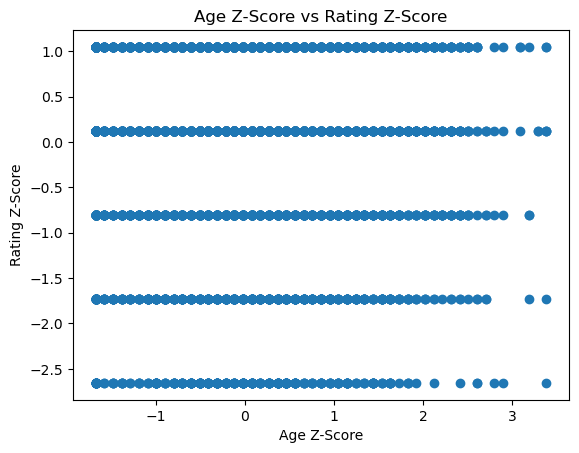

In [245]:
plt.scatter(df["Age_Z_Score"],df["Rating_Z_Score"])
plt.title("Age Z-Score vs Rating Z-Score")
plt.xlabel("Age Z-Score")
plt.ylabel("Rating Z-Score")
plt.show()

##### customer age has  no relationship with customer ratings.

# 

# 

## 4. Profitability & Business Forecasting (Profit)

#### Objective : 
Analyze profit distribution to estimate business risk, forecast future profitability, and support financial planning.

In [246]:
from scipy.stats import norm

#### 1. What is the probability that a randomly selected future order will generate a loss (Profit < 0)?

In [247]:
profit_mean = data["Profit"].mean()
profit_std = data["Profit"].std()

In [248]:
print("Average Profit : ", round(profit_mean,2))
print("Standard Deviation :",round(profit_std))

Average Profit :  1878.47
Standard Deviation : 2536


In [253]:
loss_probability = norm.cdf(x=0,loc=profit_mean,scale=profit_std)

In [254]:
loss_probability

np.float64(0.22939222020303351)

In [267]:
print('Probability of Loss :',round(loss_probability,2))
print(f'Loss Percentage :{loss_probability*100:.2f}%')

Probability of Loss : 0.23
Loss Percentage :22.94%


# 

#### 2.What is the expected loss rate for future orders?

In [272]:
loss_probability = norm.cdf(x=0,loc=profit_mean,scale=profit_std)
loss_rate = loss_probability * 100

In [274]:
print("Expected Loss Rate :",round(loss_rate,2),'%')

Expected Loss Rate : 22.94 %


# 

#### 3. What is the probability that a future order will generate more than ₹500 profit?

In [276]:
high_profit_probability = norm.sf(x= 500, loc = profit_mean, scale = profit_std)

In [277]:
high_profit_rate = high_profit_probability *100

In [282]:
print('Probability of Profit > ₹500 = : ',round(high_profit_probability,2))
print('Percentage : ',round(high_profit_rate,2),"%")

Probability of Profit > ₹500 = :  0.71
Percentage :  70.67 %


#### Alternative Method

In [286]:
high_profit_probability2 = 1 - norm.cdf(x=500,loc=profit_mean,scale=profit_std)
print(high_profit_probability2)

0.7066604927767269


# 

#### 4. What Profit value represents the top 5% of all orders (95th percentile)? / What is the minimum profit required to be in the top 5% of all orders?

In [292]:
profit_95 = norm.ppf(q=0.95,loc=profit_mean,scale=profit_std)

In [293]:
print('95th Percentile Profit :', round(profit_95,2))

95th Percentile Profit : 6049.09


In [295]:
top_profit_orders = data[data["Profit"] >= profit_95]
print(" Total Top 5% Orders :", len(top_profit_orders))


 Total Top 5% Orders : 479


In [299]:
top_profit_orders[["OrderID","Category","Region","Profit","Discount"]].sort_values(by="Profit", ascending=False).head(10)

,OrderID,Category,Region,Profit,Discount
4621,ORD102365,Electronics,East,19811.44,0.15
871,ORD100012,Electronics,East,19202.60,0.08
3608,ORD107543,Electronics,South,19137.41,0.02
4213,ORD104013,Furniture,North,18663.39,0.17
846,ORD102472,Electronics,North,17984.94,0.08
1119,ORD106354,Furniture,West,17533.80,0.02
4130,ORD105115,Electronics,East,17381.13,0.24
6404,ORD103328,Electronics,West,17055.76,0.17
3266,ORD102787,Electronics,South,16691.21,0.24
1696,ORD105350,Electronics,North,16621.46,0.02


# 

#### 5. Which Categories generate the highest-profit orders?

In [303]:
category_profit = (data.groupby("Category")["Profit"]
      .mean()
      .reset_index()
      .sort_values(by="Profit", ascending=False)
)
print(category_profit)

      Category       Profit
1  Electronics  4180.416153
2    Furniture  2909.600856
5       Sports  1102.176675
4   Home Decor   953.234166
0     Clothing   630.754094
3      Grocery   171.968268


# 

#### 6. Which Regions contribute the most to highly profitable orders?

In [306]:
region_profit = (
    data.groupby("Region")["Profit"]
      .mean()
      .reset_index()
      .sort_values(by="Profit", ascending=False)
)

In [309]:
print(region_profit)

    Region       Profit
3    South  1982.344334
1     East  1944.288856
2    North  1890.445266
0  Central  1838.809417
4     West  1751.187183
